In [ ]:
'''
Machine Learning using Python and PySpark.
Dataset: Wine Quality Dataset (Red Wine - already known):
https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv


In [1]:
# Install required packages
!pip install pyspark seaborn matplotlib pandas -q

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
import pyspark.sql.functions as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Libraries installed!")

Libraries installed!


In [2]:
# Create Spark Session
spark = SparkSession.builder \
    .appName("WineQuality_PySpark_ML") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("Spark Session Created Successfully!")

Spark Session Created Successfully!


In [3]:
# Load the dataset
import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
local_path = "winequality-red.csv"

response = requests.get(url)
with open(local_path, "wb") as f:
    f.write(response.content)

# Load the data (separator is semicolon)
df = spark.read.csv(local_path, header=True, sep=";", inferSchema=True)

print(f"Wine Quality Dataset Loaded! Total rows: {df.count()}")
df.show(5)
df.printSchema()

Wine Quality Dataset Loaded! Total rows: 1599
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|  pH|sulphates|alcohol|quality|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+----+---------+-------+-------+
|          7.4|             0.7|        0.0|           1.9|    0.076|               11.0|                34.0| 0.9978|3.51|     0.56|    9.4|      5|
|          7.8|            0.88|        0.0|           2.6|    0.098|               25.0|                67.0| 0.9968| 3.2|     0.68|    9.8|      5|
|          7.8|            0.76|       0.04|           2.3|    0.092|               15.0|                54.0|  0.997|3.26|     0.65|    9.8|      5|
|         11.2|            0.28|       0.56|          

In [4]:
# Basic statistics
df.describe().show()

# Rename target column
df = df.withColumnRenamed("quality", "label")

+-------+------------------+-------------------+-------------------+------------------+--------------------+-------------------+--------------------+--------------------+-------------------+------------------+------------------+------------------+
|summary|     fixed acidity|   volatile acidity|        citric acid|    residual sugar|           chlorides|free sulfur dioxide|total sulfur dioxide|             density|                 pH|         sulphates|           alcohol|           quality|
+-------+------------------+-------------------+-------------------+------------------+--------------------+-------------------+--------------------+--------------------+-------------------+------------------+------------------+------------------+
|  count|              1599|               1599|               1599|              1599|                1599|               1599|                1599|                1599|               1599|              1599|              1599|              1599|
|   mean

In [5]:
# Check for missing values
df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

# Create binary classification target (Good wine = quality >= 6)
df = df.withColumn("quality_class",
                   F.when(F.col("label") >= 6, 1).otherwise(0))

print("Data cleaning and feature creation completed")
df.select("label", "quality_class").groupBy("label", "quality_class").count().show()

+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-----+
|fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density| pH|sulphates|alcohol|label|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-----+
|            0|               0|          0|             0|        0|                  0|                   0|      0|  0|        0|      0|    0|
+-------------+----------------+-----------+--------------+---------+-------------------+--------------------+-------+---+---------+-------+-----+

Data cleaning and feature creation completed
+-----+-------------+-----+
|label|quality_class|count|
+-----+-------------+-----+
|    6|            1|  638|
|    7|            1|  199|
|    4|            0|   53|
|    8|            1|   18|
|    5|            0|  

In [6]:
# Predict the quality score: Regression model
feature_cols = [col for col in df.columns if col not in ['label', 'quality_class']]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")

rf_reg = RandomForestRegressor(featuresCol="scaled_features",
                               labelCol="label",
                               numTrees=100,
                               maxDepth=10,
                               seed=42)

pipeline_reg = Pipeline(stages=[assembler, scaler, rf_reg])

train, test = df.randomSplit([0.8, 0.2], seed=42)

model_reg = pipeline_reg.fit(train)
predictions_reg = model_reg.transform(test)

# Evaluation
evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction")
rmse = evaluator.evaluate(predictions_reg, {evaluator.metricName: "rmse"})
r2 = evaluator.evaluate(predictions_reg, {evaluator.metricName: "r2"})

# test icons in text
print(f"🎯 Regression RMSE: {rmse:.4f}")
print(f"🎯 Regression R²:   {r2:.4f}")

🎯 Regression RMSE: 0.6015
🎯 Regression R²:   0.4831


In [7]:
# Classification model: Good/Bad wine
rf_clf = RandomForestClassifier(featuresCol="scaled_features",
                                labelCol="quality_class",
                                numTrees=100,
                                maxDepth=10,
                                seed=42)

pipeline_clf = Pipeline(stages=[assembler, scaler, rf_clf])

model_clf = pipeline_clf.fit(train)
predictions_clf = model_clf.transform(test)

evaluator_clf = MulticlassClassificationEvaluator(labelCol="quality_class",
                                                  predictionCol="prediction",
                                                  metricName="accuracy")

accuracy = evaluator_clf.evaluate(predictions_clf)
print(f"🎯 Classification Accuracy: {accuracy:.4f}")

🎯 Classification Accuracy: 0.8073


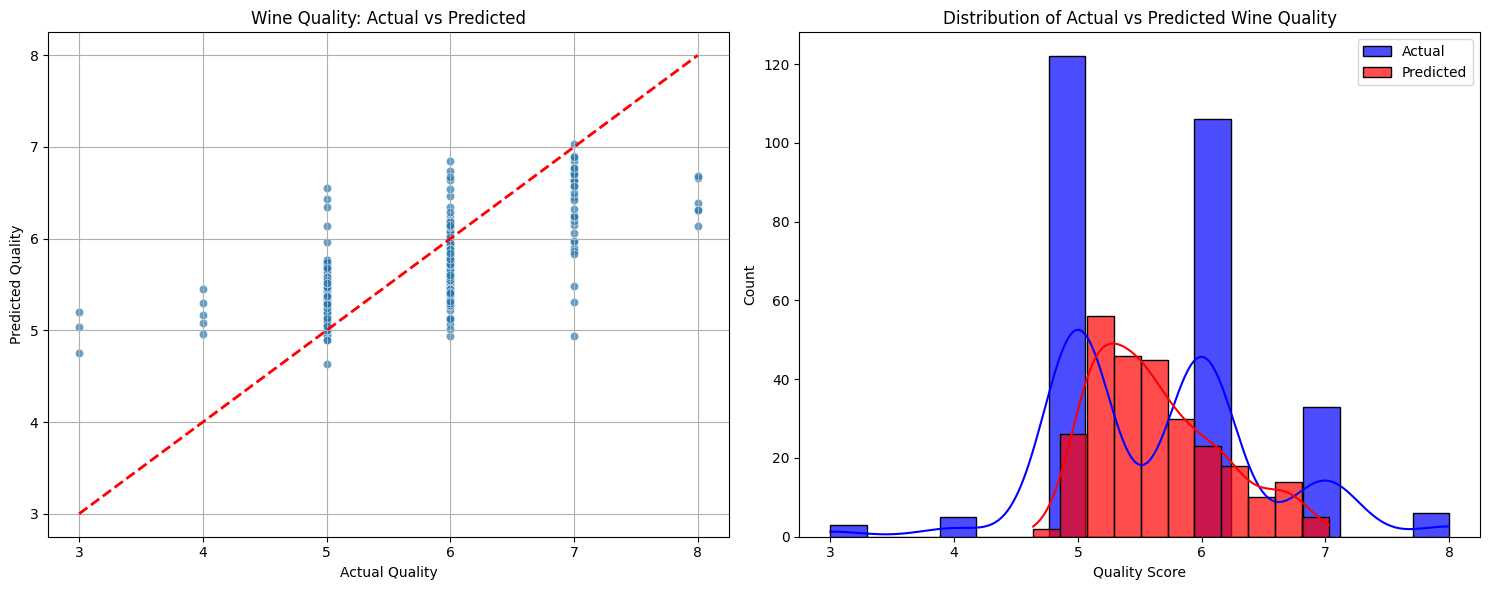

In [8]:
# Visualizations
# Convert to Pandas for plotting
pred_reg_pd = predictions_reg.select("label", "prediction").toPandas()

plt.figure(figsize=(15, 6))

# Actual vs Predicted (Regression)
plt.subplot(1, 2, 1)
sns.scatterplot(x=pred_reg_pd['label'], y=pred_reg_pd['prediction'], alpha=0.7)
plt.plot([3, 8], [3, 8], 'r--', linewidth=2)
plt.title('Wine Quality: Actual vs Predicted')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.grid(True)

# Distribution
plt.subplot(1, 2, 2)
sns.histplot(pred_reg_pd['label'], kde=True, color='blue', label='Actual', alpha=0.7)
sns.histplot(pred_reg_pd['prediction'], kde=True, color='red', label='Predicted', alpha=0.7)
plt.title('Distribution of Actual vs Predicted Wine Quality')
plt.xlabel('Quality Score')
plt.legend()

plt.tight_layout()
plt.show()

🔝 Top Feature Importances:
                 Feature  Importance
10               alcohol    0.235926
9              sulphates    0.154564
1       volatile acidity    0.119340
7                density    0.076170
6   total sulfur dioxide    0.071998
0          fixed acidity    0.068779
2            citric acid    0.063791
4              chlorides    0.060875


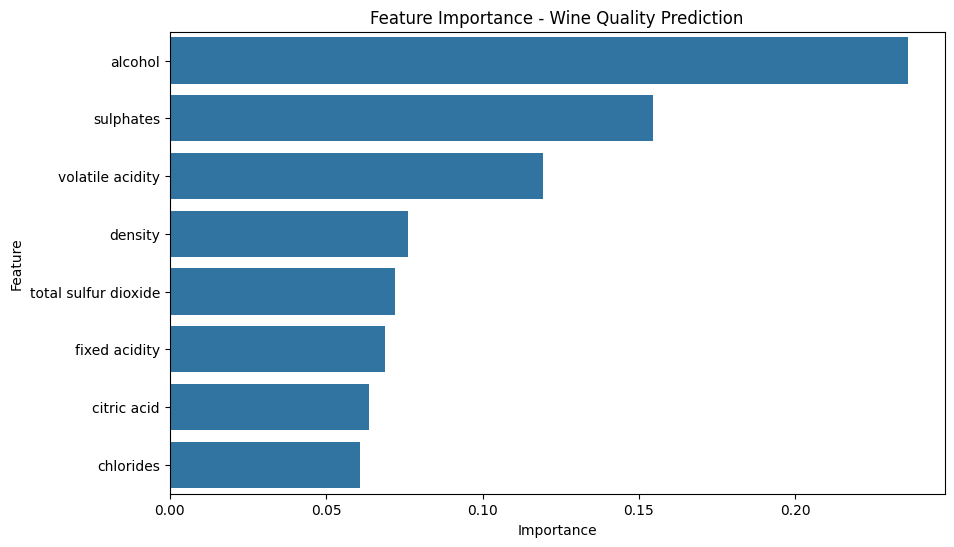

In [9]:
# Feature Importance from Regression Model
rf_model = model_reg.stages[-1]
importances = rf_model.featureImportances.toArray()

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("🔝 Top Feature Importances:")
print(feature_importance.head(8))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(8))
plt.title('Feature Importance - Wine Quality Prediction')
plt.show()

In [10]:
# Save models
model_reg.write().overwrite().save("wine_quality_regression_model")
model_clf.write().overwrite().save("wine_quality_classification_model")

# Save predictions (simple version)
predictions_reg.select("label", "prediction").write.mode("overwrite").csv("wine_predictions", header=True)

print("Models and predictions saved successfully!")

Models and predictions saved successfully!
